<a href="https://colab.research.google.com/github/BCanavan/Belinda_INFO4670_Fall2024/blob/main/Assignment_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [ ]:
# Write your code here

from google.colab import files
uploaded = files.upload()

# Here I've just loaded the dataset and looked at the first few rows, column
#types, and counts for each category (region, type, year).


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

   Column 1        Date  AveragePrice  Total Volume     4046       4225  \
0         0  12-27-2015          1.33      64236.62  1036.74   54454.85   
1         1  12-20-2015          1.35      54876.98   674.28   44638.81   
2         2  12-13-2015          0.93     118220.22   794.70  109149.67   
3         3   12-6-2015          1.08      78992.15  1132.00   71976.41   
4         4  11-29-2015          1.28      51039.60   941.48   43838.39   

     4770  Total Bags  Small Bags  Large Bags  XLarge Bags          type  \
0   48.16     8696.87     8603.62       93.25          0.0  conventional   
1   58.33     9505.56     9408.07       97.49          0.0  conventional   
2  130.50     8145.35     8042.21      103.14          0.0  conventional   
3   72.58     5811.16     5677.40      133.76          0.0  conventional   
4   75.78     6183.95     5986.26      197.69          0.0  conventional   

   year  region  
0  2015  Albany  
1  2015  Albany  
2  2015  Albany  
3  2015  Albany  
4 

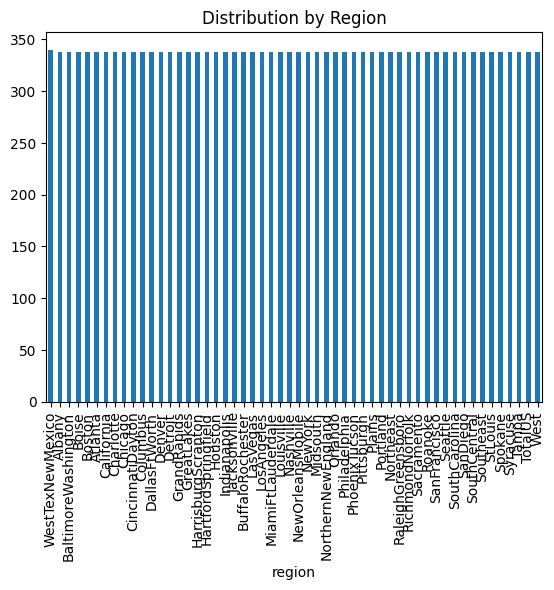

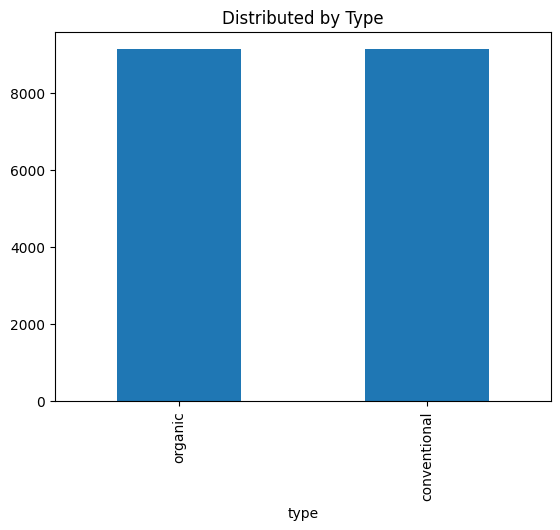

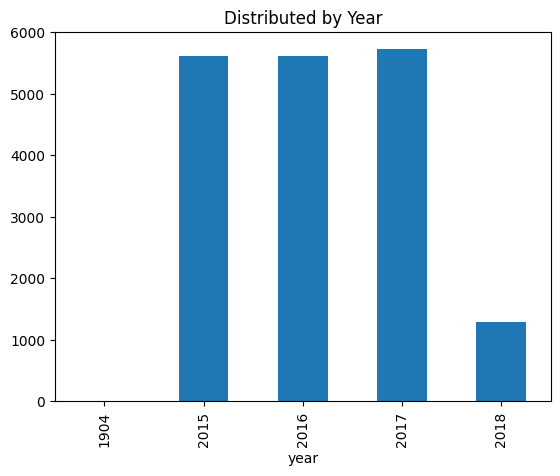

In [ ]:
# Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Assignment 2 dataset.csv")

print(df.head())
print(df.info())

print(df['region'].value_counts())

if 'type' in df.columns:
  print(df['type'].value_counts())

if 'year' in df.columns:
  print(df['year'].value_counts())

df['region'].value_counts().plot(kind='bar', title='Distribution by Region')
plt.show()

if 'type' in df.columns:
  df['type'].value_counts().plot(kind='bar', title='Distributed by Type')
  plt.show()

if 'year' in df.columns:
  df['year'].value_counts().sort_index().plot(kind='bar', title='Distributed by Year')
  plt.show()

# I was able to count some duplicated rows (2) and missing values.
# Duplicates were removed, missing values handled later.

1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [ ]:
# Write your code here
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows", num_duplicates)

missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

missing_percent = (df.isnull().sum() / len(df))*100
print(missing_percent.round(2))

#This dataset has 18,254 rows and 14 columns. This is a reasonable size for
#basic machine learning models

Number of duplicate rows 0

Missing values per column:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64
Date            0.0
AveragePrice    0.0
Total Volume    0.0
4046            0.0
4225            0.0
4770            0.0
Total Bags      0.0
Small Bags      0.0
Large Bags      0.0
XLarge Bags     0.0
type            0.0
year            0.0
region          0.0
dtype: float64


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [ ]:
# Write your code here

rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

# I removed column 1 because it likely was just an inex, and I treated year as
# a categorical variable since it represents a label, not a number for
# calculation

Number of rows: 18250
Number of columns: 13


#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [ ]:
# Write your code here
df = df.drop(columns=['Column 1'])
df['year'] = df['year'].astype('category')
df.dtypes

# Here I removed column 1 because it was likely just an index, and
# treated year asa categorical variable since it represents a label.

,0
Date,datetime64[ns]
AveragePrice,float64
Total Volume,float64
4046,float64
4225,float64
4770,float64
Total Bags,float64
Small Bags,float64
Large Bags,float64
XLarge Bags,float64


2.2 Check for duplicate values and remove them.

In [ ]:
# Write your code here
print("Duplicaterows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal", df.duplicated().sum())

# Duplicate rows are dropped here to avoid biasing the model with repeated data

Duplicaterows before removal: 2
Duplicate rows after removal 0


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [ ]:
# Write your code here
missing_per_row = df.isnull().sum(axis=1)

threshold = df.shape[1]/2

df = df[missing_per_row <= threshold]

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
  df[col] = df. groupby('region')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values after cleaning:")
print(df.isnull().sum())

# I removed rows with missing values and filled them in with the median for the
# same region. Now there are no missing values here.

Missing values after cleaning:
Column 1        0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


In [ ]:
# Write your code here
numeric_cols = df.select_dtypes(include=['float64', "int64"]).columns

corr_matrix = df[numeric_cols].corr()

print(corr_matrix)

# I calculated the correlations between numeric columns.
# Some columns (total volumeand small bags) are highly correlated.
# This can effect the model accuracy through redundancy.

              Column 1  AveragePrice  Total Volume      4046      4225  \
Column 1      1.000000     -0.133151      0.014075  0.017652  0.019868   
AveragePrice -0.133151      1.000000     -0.192772 -0.208328 -0.172949   
Total Volume  0.014075     -0.192772      1.000000  0.977863  0.974181   
4046          0.017652     -0.208328      0.977863  1.000000  0.926110   
4225          0.019868     -0.172949      0.974181  0.926110  1.000000   
4770          0.041783     -0.179463      0.872203  0.833390  0.887856   
Total Bags   -0.002180     -0.177108      0.963047  0.920057  0.905788   
Small Bags    0.000372     -0.174743      0.967238  0.925280  0.916032   
Large Bags   -0.009170     -0.172953      0.880640  0.838646  0.810016   
XLarge Bags  -0.011515     -0.117608      0.747159  0.699379  0.688811   
year         -0.172000      0.093489      0.017109  0.003303 -0.009635   

                  4770  Total Bags  Small Bags  Large Bags  XLarge Bags  \
Column 1      0.041783   -0.002180  

#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

In [ ]:
# Write your code here
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns

print("Numeric/Continuous Variables:")
for col in numeric_cols:
  print(f"{col}: min={df[col].min()}, mean={df[col].mean():.2f}, median={df[col].median():.2f}")
  print(f"  Sample distribution: {df[col].head(10).values}")
  print("-" * 40)

print("\nCategorical Variables:")
for col in categorical_cols:
  print(f"{col}: unique values = {df[col].unique()}, count = {df[col].nunique()}")
  print("-" * 40)

  # Continuous variables = min, mean, median, and sample distributions
  # Categorical variables = sumamrized by listing unique values


Numeric/Continuous Variables:
Column 1: min=0, mean=24.23, median=24.00
  Sample distribution: [0 1 2 3 4 5 6 7 8 9]
----------------------------------------
AveragePrice: min=0.44, mean=1.41, median=1.37
  Sample distribution: [1.33 1.35 0.93 1.08 1.28 1.26 0.99 0.98 1.02 1.07]
----------------------------------------
Total Volume: min=84.56, mean=850506.78, median=107330.17
  Sample distribution: [ 64236.62  54876.98 118220.22  78992.15  51039.6   55979.78  83453.76
 109428.33  99811.42  74338.76]
----------------------------------------
4046: min=0.0, mean=292976.51, median=8641.10
  Sample distribution: [1036.74  674.28  794.7  1132.    941.48 1184.27 1368.92  703.75 1022.15
  842.4 ]
----------------------------------------
4225: min=0.0, mean=295106.49, median=29055.72
  Sample distribution: [ 54454.85  44638.81 109149.67  71976.41  43838.39  48067.99  73672.72
 101815.36  87315.57  64757.44]
----------------------------------------
4770: min=0.0, mean=22836.02, median=184.98
  S

3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [ ]:
# Write your code here
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')

earliest_date = df['Date'].min()
print("Earliest date in dataset:", earliest_date)

pre_2010 = df[df['Date'].dt.year < 2010]
print("Number of records before 2010:", len(pre_2010))
print(pre_2010[['Date', 'AveragePrice', 'region', 'type']])

df = df[df["Date"].dt.year >= 2010]

print("Earliest date after cleaning:", df["Date"].min())

# The earliest date was in 1904, which does not fit the data.
# Only one record existed before 2010, so it was removed.
# The next earliest valid date was in 2015.


Earliest date in dataset: 1904-01-21 00:00:00
Number of records before 2010: 1
            Date  AveragePrice            region     type
18250 1904-01-21          1.87  WestTexNewMexico  organic
Earliest date after cleaning: 2015-01-04 00:00:00


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [ ]:
# Write your code here
max_price = df['AveragePrice'].max()
print("Highest AveragePrice:", max_price)

region_max = df[df['AveragePrice'] == max_price]['region'].values
print("Region(s) with highest price:", region_max)

#The highest pice was $3.25 in San Franscisco.

Highest AveragePrice: 3.25
Region(s) with highest price: ['SanFrancisco']


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [ ]:
# Write your code here
max_volume = df['Total Volume'].max()
print("Highest Total Volume:", max_volume)

region_max_volume = df[df['Total Volume'] == max_volume]['region'].values
print("Region(s) with highest total volume:", region_max_volume)

#The highest total volume occurs in TotalUS, which aggregates all regions.

Highest Total Volume: 62505646.52
Region(s) with highest total volume: ['TotalUS']
